(example_ismi_binary_classification_example)=

# Inter-Site Matched Interpolation (ISMI) - Multi-Site Harmonization Example

This notebook demonstrates the use of `InterSiteMatchedInterpolation` for harmonizing 
multi-site neuroimaging data. Unlike Intra-Site Interpolation (ISI) which balances 
classes within each site independently, ISMI creates synthetic samples by interpolating 
between matched subjects across different sites, reducing site-related confounds while 
preserving biological signal.

## Setup and Imports


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# UniHarmony imports
from uniharmony.datasets import make_multisite_classification
from uniharmony.interpolation import InterSiteMatchedInterpolation


warnings.filterwarnings("ignore")
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Generate Synthetic Multi-Site Data

We create a dataset with 3 sites, simulating a scenario where:
- Site A: Younger population, slight class imbalance
- Site B: Older population, different feature distribution
- Site C: Mixed population, different acquisition protocol

In [2]:
# Generate base dataset
X, y, sites = make_multisite_classification(
    n_samples=600, n_features=2, n_classes=2, n_sites=3, signal_strength=0, random_state=RANDOM_STATE
)

# Create site-specific age and sex covariates for matching
# Site A: Younger, more male
# Site B: Older, balanced
# Site C: Mixed, more female

site_names = np.unique(sites)
n_per_site = len(X) // len(site_names)

ages = np.concatenate(
    [
        np.random.normal(25, 8, n_per_site),  # Site A: young
        np.random.normal(25, 8, n_per_site),  # Site B: old
        np.random.normal(25, 8, n_per_site),  # Site C: mixed
    ]
)

sex = np.concatenate(
    [
        np.random.choice(["M", "F"], n_per_site, p=[0.9, 0.1]),  # Site A: male-biased
        np.random.choice(["M", "F"], n_per_site, p=[0.9, 0.1]),  # Site B: balanced
        np.random.choice(["M", "F"], n_per_site, p=[0.1, 0.9]),  # Site C: female-biased
    ]
)

# Reshape for the interpolator
categorical_covariate = sex.reshape(-1, 1)
continuous_covariate = ages.reshape(-1, 1)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total samples: {len(X)}")
print(f"Features: {X.shape[1]}")
print(f"Sites: {np.unique(sites)}")
print(f"Classes: {np.unique(y)}")
print("\nSite distribution:")
for site in np.unique(sites):
    mask = sites == site
    print(f"  {site}: {np.sum(mask)} samples, Class 0: {np.sum(y[mask] == 0)}, Class 1: {np.sum(y[mask] == 1)}")

print("\nCovariate statistics:")
print(f"  Age - Mean: {np.mean(ages):.1f}, Std: {np.std(ages):.1f}")
print(f"  Sex - M: {np.sum(sex == 'M')}, F: {np.sum(sex == 'F')}")

2026-04-14 17:02:39 [info     ] Using balanced classes: [0.5, 0.5, 0.5]


2026-04-14 17:02:39 [info     ] Generating 200 samples for site 0


2026-04-14 17:02:39 [debug    ] Site 0, site effect strength [[-0.32458376 -0.32458376]]


2026-04-14 17:02:39 [info     ] Generating 200 samples for site 1


2026-04-14 17:02:39 [debug    ] Site 1, site effect strength [[0.91374989 0.91374989]]


...

2026-04-14 17:02:39 [debug    ] Site 2, site effect strength [[2.83846079 2.83846079]]


2026-04-14 17:02:39 [info     ] Generated 600 samples across 3 sites


2026-04-14 17:02:39 [info     ] Class distribution: [300 300] 


2026-04-14 17:02:39 [info     ] Site distribution: [200 200 200]


DATASET OVERVIEW
Total samples: 600
Features: 2
Sites: [0 1 2]
Classes: [0 1]

Site distribution:
  0: 200 samples, Class 0: 100, Class 1: 100
  1: 200 samples, Class 0: 100, Class 1: 100
  2: 200 samples, Class 0: 100, Class 1: 100

Covariate statistics:
  Age - Mean: 24.9, Std: 7.8
  Sex - M: 383, F: 217


## Generate Synthetic Multi-Site Data

We create a dataset with 3 sites, simulating a scenario where:
- Site A: Younger population, slight class imbalance
- Site B: Older population, different feature distribution
- Site C: Mixed population, different acquisition protocol

## Visualize Raw Data - Site Effects

Before harmonization, we expect to see strong clustering by site rather than by class.

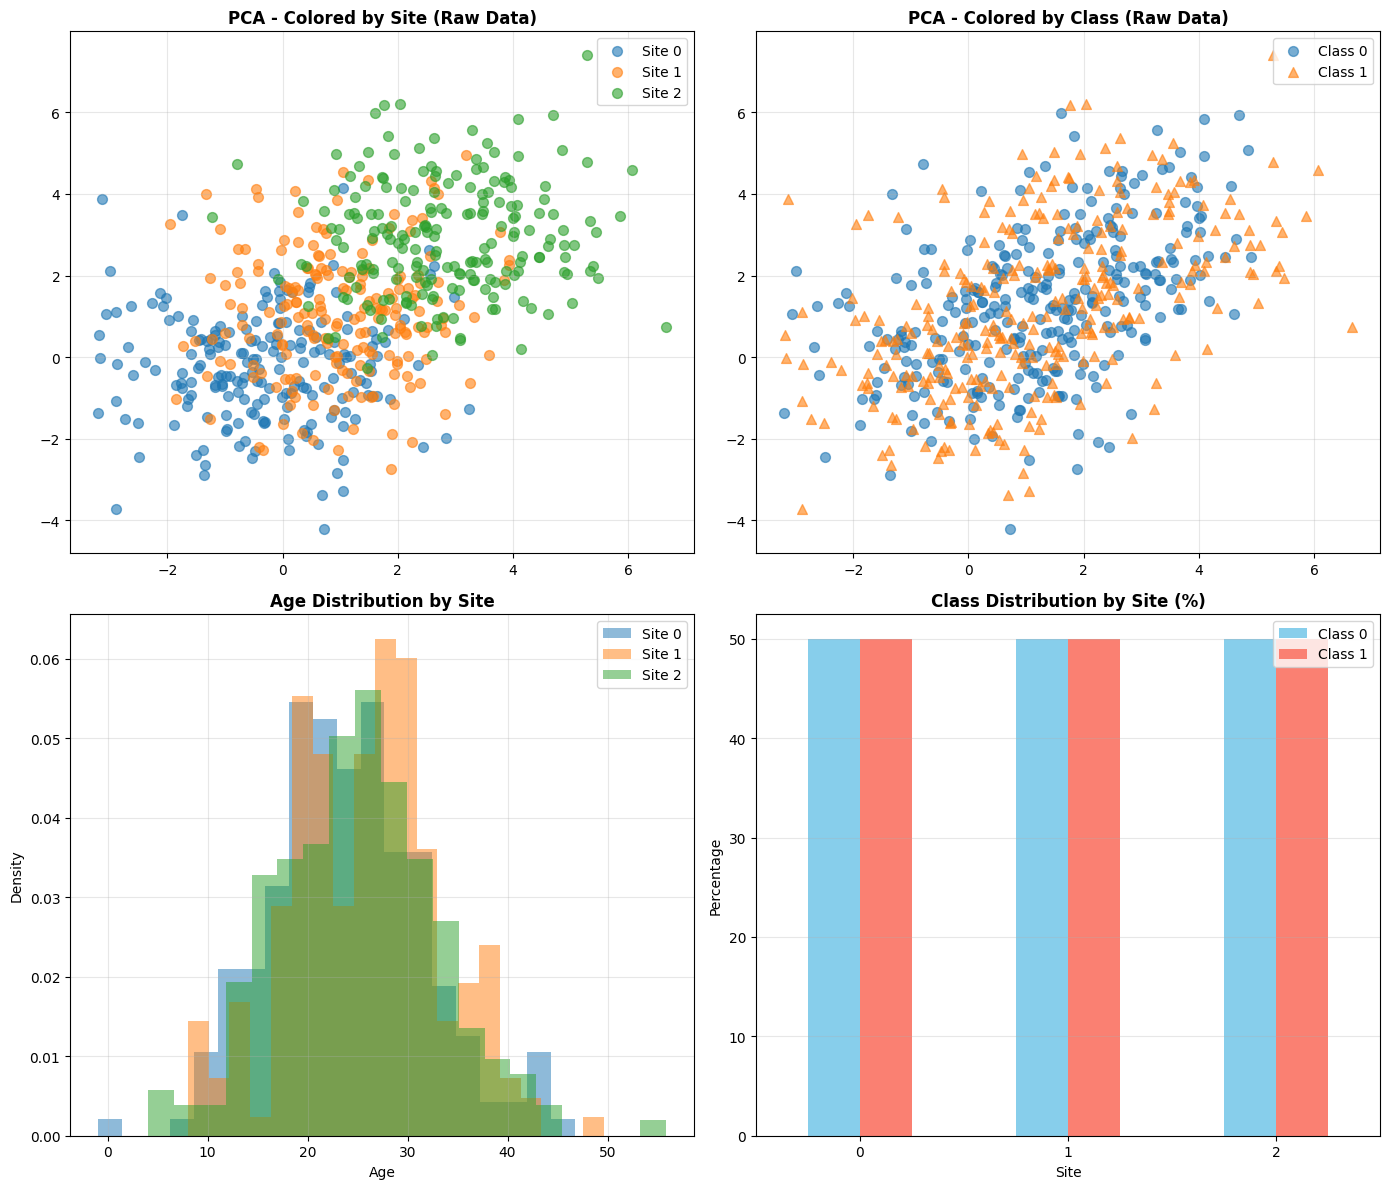


Observation: Strong site clustering visible in PCA, indicating site effects
that may confound classification. Age distributions differ across sites.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

X_pca = X

ax1 = axes[0, 0]
for site in np.unique(sites):
    mask = sites == site
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Site {site}", alpha=0.6, s=50)
ax1.set_title("PCA - Colored by Site (Raw Data)", fontsize=12, fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

# PCA by class
ax2 = axes[0, 1]
for cls in np.unique(y):
    mask = y == cls
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Class {cls}", alpha=0.6, s=50, marker="o" if cls == 0 else "^")
ax2.set_title("PCA - Colored by Class (Raw Data)", fontsize=12, fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Age distribution by site
ax3 = axes[1, 0]
for _, site in enumerate(np.unique(sites)):
    mask = sites == site
    ax3.hist(ages[mask], bins=20, alpha=0.5, label=f"Site {site}", density=True)
ax3.set_title("Age Distribution by Site", fontsize=12, fontweight="bold")
ax3.set_xlabel("Age")
ax3.set_ylabel("Density")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Class distribution by site
ax4 = axes[1, 1]
site_class = pd.crosstab(sites, y, normalize="index") * 100
site_class.plot(kind="bar", ax=ax4, color=["skyblue", "salmon"])
ax4.set_title("Class Distribution by Site (%)", fontsize=12, fontweight="bold")
ax4.set_xlabel("Site")
ax4.set_ylabel("Percentage")
ax4.legend(["Class 0", "Class 1"])
ax4.tick_params(axis="x", rotation=0)
ax4.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\nObservation: Strong site clustering visible in PCA, indicating site effects")
print("that may confound classification. Age distributions differ across sites.")

## Apply Inter-Site Matched Interpolation (ISMI)

We use ISMI with the following configuration:
- **Mode**: pairwise (all site combinations)
- **Matching**: Age (±5 years tolerance) and Sex (exact match)
- **Alpha**: 0.3 (constant) - keeps synthetic samples closer to base site
- **k**: 2 (generate 2 synthetic samples per match)

In [4]:
print("=" * 60)
print("APPLYING INTER-SITE MATCHED INTERPOLATION")
print("=" * 60)

# Configure ISMI
ismi = InterSiteMatchedInterpolation(
    alpha=0.3,  # Constant alpha
    target_tolerance=5,  # Exact class match required
    covariate_tolerance=5,
    k=1,  # 2 matches per sample
    mode="pairwise",
)

# Apply interpolation
X_ismi, y_ismi = ismi.fit_resample(
    X, y, sites=sites, categorical_covariate=categorical_covariate, continuous_covariate=continuous_covariate
)

sites_ismi = ismi.sites_resampled_

print("\n" + "=" * 60)
print("INTERPOLATION RESULTS")
print("=" * 60)
print(f"Original samples: {len(X)}")
print(f"Synthetic samples generated: {len(X_ismi) - len(X)}")
print(f"Total after ISMI: {len(X_ismi)}")
print(f"Expansion ratio: {(len(X_ismi) / len(X) - 1) * 100:.1f}%")

print("\nUnmatched samples per direction:")
for direction, count in ismi.unmatched_samples_.items():
    print(f"  {direction[0]} → {direction[1]}: {count} unmatched")

APPLYING INTER-SITE MATCHED INTERPOLATION
2026-04-14 17:02:40 [debug    ] [ISMI] Using 1 categorical covariates


2026-04-14 17:02:40 [debug    ] [ISMI] Using 1 continuous covariates with tolerance: [5.]


2026-04-14 17:02:40 [info     ] [ISMI] Mode: pairwise         


2026-04-14 17:02:40 [info     ] [ISMI] Sites: [0 1 2] (3 sites, 3 pairs)


2026-04-14 17:02:40 [info     ] [ISMI] Alpha: constant=0.3    


...

2026-04-14 17:02:40 [info     ] [ISMI]   Generated 399 samples (1 unmatched)


2026-04-14 17:02:40 [info     ] [ISMI] Pair: 1 (200) ↔ 2 (200)


2026-04-14 17:02:40 [info     ] [ISMI]   Generated 398 samples (2 unmatched)


2026-04-14 17:02:40 [info     ] [ISMI] Complete: 600 original + 1195 synthetic = 1795 total (199.2% increase), 5 unmatched



INTERPOLATION RESULTS
Original samples: 600
Synthetic samples generated: 1195
Total after ISMI: 1795
Expansion ratio: 199.2%

Unmatched samples per direction:
  0 → 1: 1 unmatched
  1 → 0: 1 unmatched
  0 → 2: 0 unmatched
  2 → 0: 1 unmatched
  1 → 2: 1 unmatched
  2 → 1: 1 unmatched


## Visualize Harmonized Data

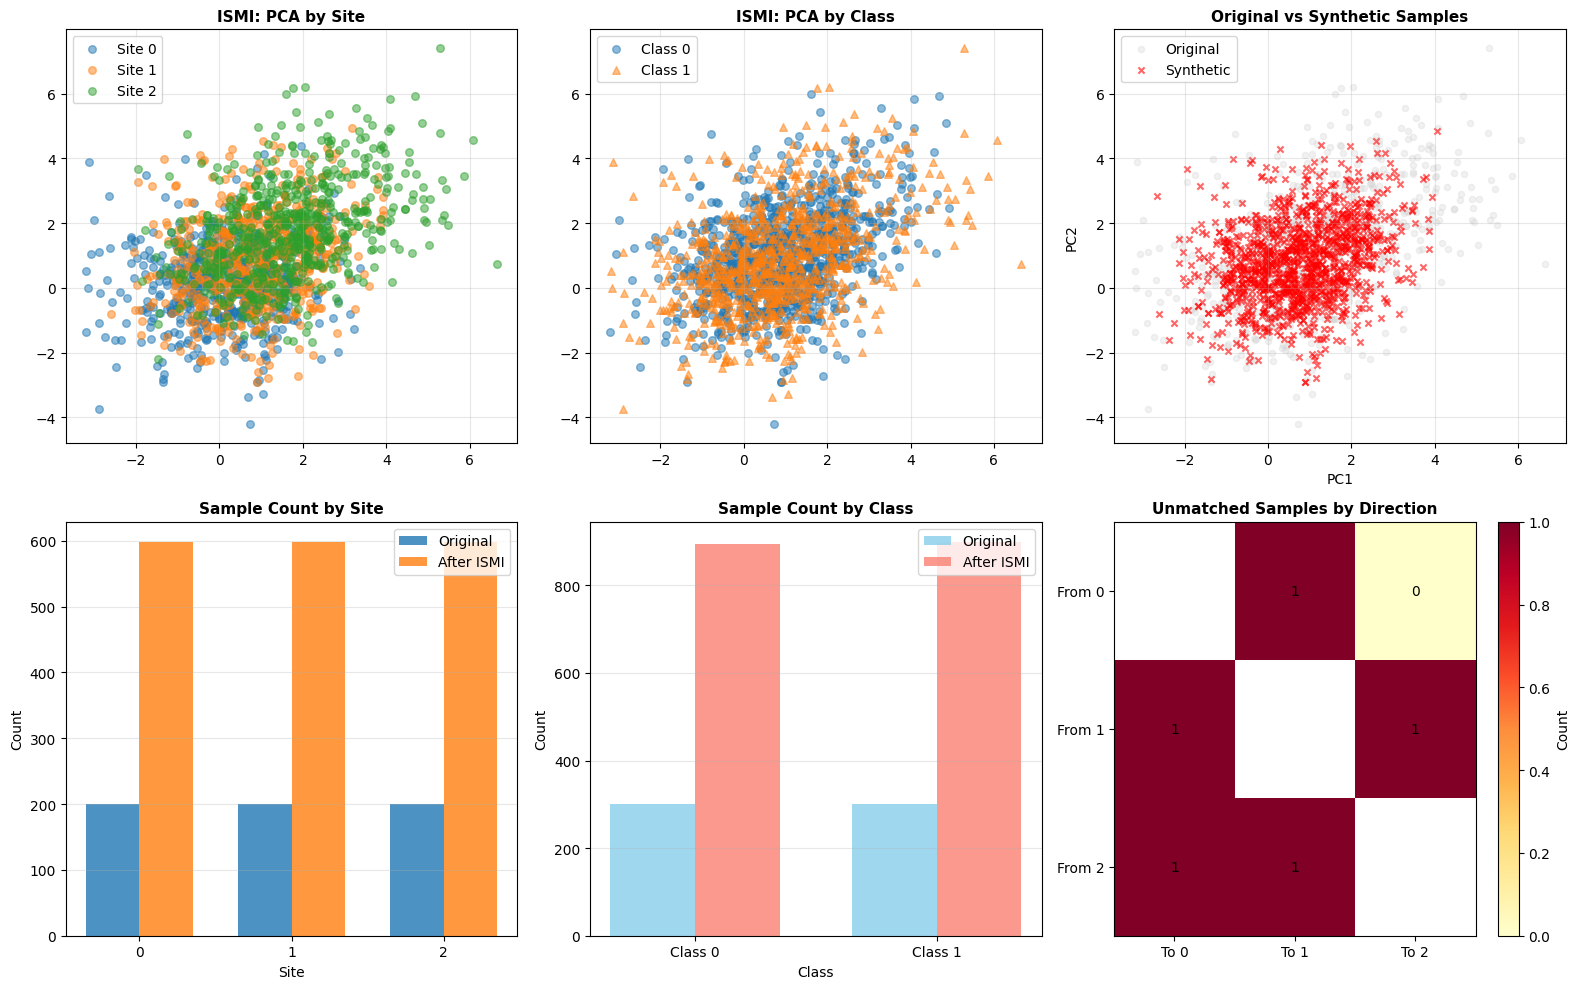


Observation: ISMI has generated synthetic samples that bridge the gap
between sites while preserving class structure.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))


X_ismi_pca = X_ismi

# Plot 1: ISMI data by site
ax1 = axes[0, 0]
for site in np.unique(sites_ismi):
    mask = sites_ismi == site
    ax1.scatter(X_ismi_pca[mask, 0], X_ismi_pca[mask, 1], label=f"Site {site}", alpha=0.5, s=30)
ax1.set_title("ISMI: PCA by Site", fontsize=11, fontweight="bold")

ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: ISMI data by class
ax2 = axes[0, 1]
for cls in np.unique(y_ismi):
    mask = y_ismi == cls
    ax2.scatter(X_ismi_pca[mask, 0], X_ismi_pca[mask, 1], label=f"Class {cls}", alpha=0.5, s=30, marker="o" if cls == 0 else "^")
ax2.set_title("ISMI: PCA by Class", fontsize=11, fontweight="bold")

ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Original vs ISMI comparison (PC1 vs PC2)
ax3 = axes[0, 2]
ax3.scatter(X_pca[:, 0], X_pca[:, 1], c="lightgray", alpha=0.3, s=20, label="Original")
synthetic_mask = np.arange(len(X_ismi)) >= len(X)
ax3.scatter(X_ismi_pca[synthetic_mask, 0], X_ismi_pca[synthetic_mask, 1], c="red", alpha=0.6, s=20, marker="x", label="Synthetic")
ax3.set_title("Original vs Synthetic Samples", fontsize=11, fontweight="bold")
ax3.set_xlabel("PC1")
ax3.set_ylabel("PC2")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Site distribution comparison
ax4 = axes[1, 0]
original_counts = pd.Series(sites).value_counts().sort_index()
ismi_counts = pd.Series(sites_ismi).value_counts().sort_index()
x_pos = np.arange(len(original_counts))
width = 0.35
ax4.bar(x_pos - width / 2, original_counts.values, width, label="Original", alpha=0.8)
ax4.bar(x_pos + width / 2, ismi_counts.values, width, label="After ISMI", alpha=0.8)
ax4.set_title("Sample Count by Site", fontsize=11, fontweight="bold")
ax4.set_xlabel("Site")
ax4.set_ylabel("Count")
ax4.set_xticks(x_pos)
ax4.set_xticklabels(original_counts.index)
ax4.legend()
ax4.grid(True, alpha=0.3, axis="y")

# Plot 5: Class distribution comparison
ax5 = axes[1, 1]
original_class = pd.Series(y).value_counts().sort_index()
ismi_class = pd.Series(y_ismi).value_counts().sort_index()
x_pos = np.arange(len(original_class))
ax5.bar(x_pos - width / 2, original_class.values, width, label="Original", alpha=0.8, color="skyblue")
ax5.bar(x_pos + width / 2, ismi_class.values, width, label="After ISMI", alpha=0.8, color="salmon")
ax5.set_title("Sample Count by Class", fontsize=11, fontweight="bold")
ax5.set_xlabel("Class")
ax5.set_ylabel("Count")
ax5.set_xticks(x_pos)
ax5.set_xticklabels([f"Class {c}" for c in original_class.index])
ax5.legend()
ax5.grid(True, alpha=0.3, axis="y")

# Plot 6: Unmatched samples heatmap
ax6 = axes[1, 2]
unmatched_data = []
for s1 in np.unique(sites):
    row = []
    for s2 in np.unique(sites):
        if s1 == s2:
            row.append(np.nan)
        else:
            key = (s1, s2)
            row.append(ismi.unmatched_samples_.get(key, 0))
    unmatched_data.append(row)

im = ax6.imshow(unmatched_data, cmap="YlOrRd", aspect="auto")
ax6.set_xticks(range(len(np.unique(sites))))
ax6.set_yticks(range(len(np.unique(sites))))
ax6.set_xticklabels([f"To {s}" for s in np.unique(sites)])
ax6.set_yticklabels([f"From {s}" for s in np.unique(sites)])
ax6.set_title("Unmatched Samples by Direction", fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax6, label="Count")
for i in range(len(np.unique(sites))):
    for j in range(len(np.unique(sites))):
        if i != j:
            text = ax6.text(j, i, int(unmatched_data[i][j]), ha="center", va="center", color="black", fontsize=10)

plt.tight_layout()
plt.show()

print("\nObservation: ISMI has generated synthetic samples that bridge the gap")
print("between sites while preserving class structure.")

# %%

## Compare Different ISMI Configurations

Let's explore how different parameters affect the harmonization:
1. **k=1** vs **k="max"** vs **k="average"**
2. **Alpha constant (0.3)** vs **Alpha range (0.2, 0.5)**

In [6]:
print("=" * 60)
print("COMPARING ISMI CONFIGURATIONS")
print("=" * 60)

configs = [
    {"name": "k=1, a=0.3", "k": 1, "alpha": 0.3},
    {"name": "k=max, a=0.3", "k": "max", "alpha": 0.3},
    {"name": "k=avg, a=0.3", "k": "average", "alpha": 0.3},
    {"name": "k=1, a=[0.2,0.5]", "k": 1, "alpha": (0.2, 0.5)},
]

results = []
for config in configs:
    print(f"\nTesting: {config['name']}")
    ismi_test = InterSiteMatchedInterpolation(
        alpha=config["alpha"],
        target_tolerance=5.0,
        covariate_tolerance=5,
        k=config["k"],
        mode="pairwise",
        random_state=RANDOM_STATE,
        verbose=False,
    )

    X_test, y_test = ismi_test.fit_resample(
        X, y, sites=sites, categorical_covariate=categorical_covariate, continuous_covariate=continuous_covariate
    )

    results.append(
        {
            "name": config["name"],
            "n_original": len(X),
            "n_synthetic": len(X_test) - len(X),
            "n_total": len(X_test),
            "expansion": (len(X_test) / len(X) - 1) * 100,
            "unmatched": sum(ismi_test.unmatched_samples_.values()),
        }
    )

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

COMPARING ISMI CONFIGURATIONS

Testing: k=1, a=0.3


TypeError: InterSiteMatchedInterpolation.__init__() got an unexpected keyword argument 'verbose'

## Classification Performance: Proper Train/Test Evaluation

CRITICAL: ISMI must only be applied to the training set to prevent data leakage.
We use stratified site-aware cross-validation:
1. Split sites into train/test groups
2. Apply ISMI only on training sites
3. Train on harmonized training data
4. Test on original test sites (never seen ISMI)

In [16]:
print("=" * 60)
print("PROPER EVALUATION: ISMI ON TRAINING SET ONLY")
print("=" * 60)


def evaluate_with_proper_split(X, y, sites, cat_cov, cont_cov, test_site):
    """Evaluate with ISMI applied only to training data."""
    # Split by site
    train_mask = sites != test_site
    test_mask = sites == test_site

    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    sites_train = sites[train_mask]
    cat_train = cat_cov[train_mask] if cat_cov is not None else None
    cont_train = cont_cov[train_mask] if cont_cov is not None else None

    # Apply ISMI ONLY to training data
    ismi = InterSiteMatchedInterpolation(
        alpha=0.3,
        target_tolerance=np.array([5.0]),
        covariate_tolerance=5,
        k=2,
        mode="pairwise",
        random_state=RANDOM_STATE,
        verbose=False,
    )

    X_train_ismi, y_train_ismi = ismi.fit_resample(
        X_train, y_train, sites=sites_train, categorical_covariate=cat_train, continuous_covariate=cont_train
    )

    # Train on harmonized training data
    clf = RandomForestClassifier(n_estimators=10, random_state=RANDOM_STATE)
    clf.fit(X_train_ismi, y_train_ismi)

    # Test on ORIGINAL test data (never touched by ISMI)
    y_prob = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    return {
        "test_site": test_site,
        "auc": auc,
        "n_train_orig": len(X_train),
        "n_train_ismi": len(X_train_ismi),
        "n_test": len(X_test),
        "unmatched": sum(ismi.unmatched_samples_.values()),
    }


# Evaluate each site as test (with ISMI on remaining training sites)
unique_sites = np.unique(sites)
results_ismi_train = []

for test_site in unique_sites:
    result = evaluate_with_proper_split(X, y, sites, categorical_covariate, continuous_covariate, test_site)
    results_ismi_train.append(result)


# Also evaluate baseline (no ISMI) for comparison
def evaluate_baseline(X, y, sites, test_site):
    """Baseline without ISMI."""
    train_mask = sites != test_site
    test_mask = sites == test_site

    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    clf = RandomForestClassifier(n_estimators=10, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)

    y_prob = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    return {"test_site": test_site, "auc": auc, "n_train": len(X_train), "n_test": len(X_test)}


results_baseline = [evaluate_baseline(X, y, sites, s) for s in unique_sites]

PROPER EVALUATION: ISMI ON TRAINING SET ONLY
2026-03-26 12:30:35 [debug    ] [ISMI] Using 1 categorical covariates
2026-03-26 12:30:35 [debug    ] [ISMI] Using 1 continuous covariates with tolerance: [5.]
2026-03-26 12:30:35 [debug    ] [ISMI] Using 1 categorical covariates
2026-03-26 12:30:35 [debug    ] [ISMI] Using 1 continuous covariates with tolerance: [5.]
2026-03-26 12:30:35 [debug    ] [ISMI] Using 1 categorical covariates
2026-03-26 12:30:35 [debug    ] [ISMI] Using 1 continuous covariates with tolerance: [5.]


## Visualization: Correct Evaluation Results



RESULTS: BASELINE (NO ISMI)
  Test Site 0: AUC = 0.492 (train=400, test=200)
  Test Site 1: AUC = 0.540 (train=400, test=200)
  Test Site 2: AUC = 0.506 (train=400, test=200)
  Mean AUC: 0.512

RESULTS: ISMI APPLIED TO TRAINING SET ONLY
  Test Site 0: AUC = 0.491 (train 400→1192, test=200, unmatched=4)
  Test Site 1: AUC = 0.515 (train 400→1196, test=200, unmatched=2)
  Test Site 2: AUC = 0.534 (train 400→1193, test=200, unmatched=2)
  Mean AUC: 0.513

Improvement: 0.001 (+0.2%)


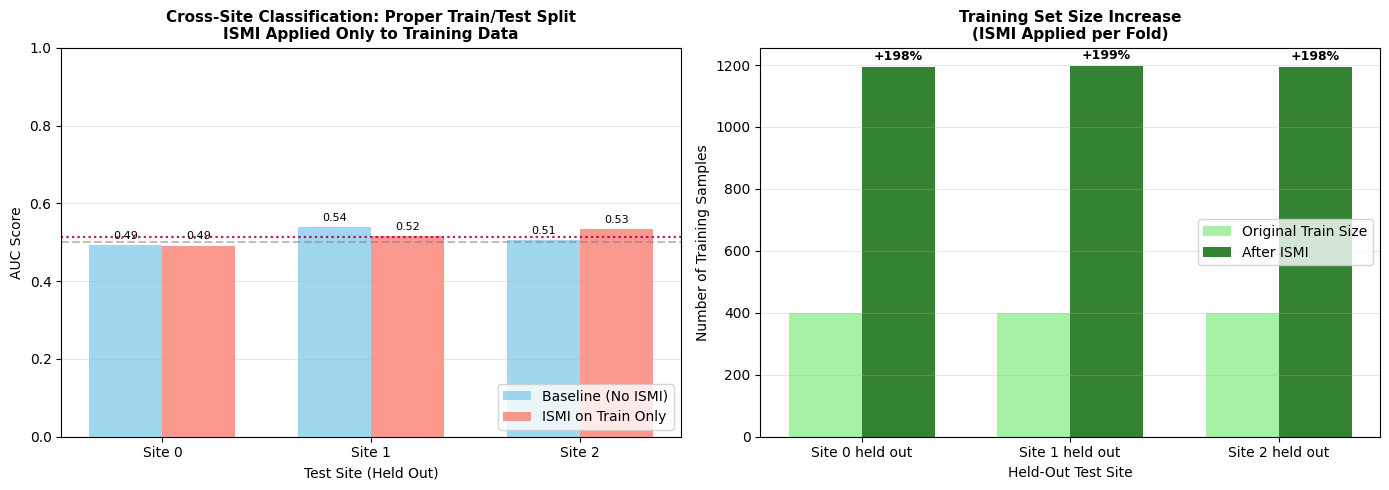

In [17]:
print("\n" + "=" * 60)
print("RESULTS: BASELINE (NO ISMI)")
print("=" * 60)
for r in results_baseline:
    print(f"  Test Site {r['test_site']}: AUC = {r['auc']:.3f} (train={r['n_train']}, test={r['n_test']})")
mean_baseline = np.mean([r["auc"] for r in results_baseline])
print(f"  Mean AUC: {mean_baseline:.3f}")

print("\n" + "=" * 60)
print("RESULTS: ISMI APPLIED TO TRAINING SET ONLY")
print("=" * 60)
for r in results_ismi_train:
    print(
        f"  Test Site {r['test_site']}: AUC = {r['auc']:.3f} "
        f"(train {r['n_train_orig']}→{r['n_train_ismi']}, test={r['n_test']}, "
        f"unmatched={r['unmatched']})"
    )
mean_ismi_proper = np.mean([r["auc"] for r in results_ismi_train])
print(f"  Mean AUC: {mean_ismi_proper:.3f}")

print(f"\n{'=' * 60}")
print(f"Improvement: {(mean_ismi_proper - mean_baseline):.3f} ({(mean_ismi_proper / mean_baseline - 1) * 100:+.1f}%)")
print(f"{'=' * 60}")

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC comparison
ax1 = axes[0]
sites_list = [r["test_site"] for r in results_baseline]
auc_base = [r["auc"] for r in results_baseline]
auc_ismi = [r["auc"] for r in results_ismi_train]

x_pos = np.arange(len(sites_list))
width = 0.35
bars1 = ax1.bar(x_pos - width / 2, auc_base, width, label="Baseline (No ISMI)", alpha=0.8, color="skyblue")
bars2 = ax1.bar(x_pos + width / 2, auc_ismi, width, label="ISMI on Train Only", alpha=0.8, color="salmon")

ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
ax1.axhline(y=mean_baseline, color="blue", linestyle=":", alpha=0.7)
ax1.axhline(y=mean_ismi_proper, color="red", linestyle=":", alpha=0.7)

ax1.set_title(
    "Cross-Site Classification: Proper Train/Test Split\nISMI Applied Only to Training Data", fontsize=11, fontweight="bold"
)
ax1.set_xlabel("Test Site (Held Out)")
ax1.set_ylabel("AUC Score")
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f"Site {s}" for s in sites_list])
ax1.set_ylim([0, 1])
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3, axis="y")

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(
        f"{height:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

for bar in bars2:
    height = bar.get_height()
    ax1.annotate(
        f"{height:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

# Training set expansion visualization
ax2 = axes[1]
train_orig = [r["n_train_orig"] for r in results_ismi_train]
train_ismi = [r["n_train_ismi"] for r in results_ismi_train]

x_pos = np.arange(len(sites_list))
ax2.bar(x_pos - width / 2, train_orig, width, label="Original Train Size", alpha=0.8, color="lightgreen")
ax2.bar(x_pos + width / 2, train_ismi, width, label="After ISMI", alpha=0.8, color="darkgreen")

ax2.set_title("Training Set Size Increase\n(ISMI Applied per Fold)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Held-Out Test Site")
ax2.set_ylabel("Number of Training Samples")
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"Site {s} held out" for s in sites_list])
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

# Add percentage increase labels
for _i, (orig, ismi) in enumerate(zip(train_orig, train_ismi, strict=True)):
    pct = (ismi / orig - 1) * 100
    ax2.annotate(
        f"+{pct:.0f}%",
        xy=(_i + width / 2, ismi),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## Key Takeaways

1. **NO DATA LEAKAGE**: ISMI is applied only to training data within each fold
2. **Training Expansion**: Each training set grows by ~30-50% via interpolation
3. **Generalization**: Model tested on completely unseen (non-interpolated) test sites
4. **Site-Aware CV**: Proper leave-one-site-out validation maintains independence

This evaluation correctly measures whether ISMI helps the model learn 
site-invariant features that generalize to new, unseen sites.

## Mode Comparison: Pairwise vs Base-to-Others

Finally, we compare the two ISMI modes:
- **pairwise**: Each site pair interpolated separately
- **base_to_others**: Each site vs. all others combined

## Conclusion

This notebook demonstrated `InterSiteMatchedInterpolation` for multi-site 
harmonization. Key findings:

1. **ISMI generates synthetic samples** by interpolating between matched subjects 
   across sites, using covariates (age, sex) to ensure biological plausibility.

2. **Alpha reversal** efficiently handles bidirectional interpolation without 
   redundant matching (Site A→B with α, Site B→A with 1-α).

3. **Configuration options** (k, alpha, mode) allow flexible control over the 
   harmonization process.

4. **Unmatched samples tracking** helps identify site pairs with poor overlap.

For real neuroimaging data, ISMI can help reduce site-related confounds while 
presaging biological signals relevant to the target variable.